In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [1]:
# STEP 1 — Install all dependencies
!pip install librosa soundfile audiomentations scikit-learn imbalanced-learn xgboost lightgbm -q
!pip install tensorflow keras numpy pandas matplotlib seaborn tqdm joblib -q
import warnings, os
warnings.filterwarnings('ignore')
print('All dependencies installed!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 13.0 MB/s eta 0:00:00
All dependencies installed!


In [8]:
# STEP 2 — Mount Google Drive and access the dataset folder
import os
from google.colab import drive
drive.mount('/content/drive')

# --- CHANGE THIS to your folder path in Google Drive ---
DRIVE_FOLDER_PATH = '/content/drive/MyDrive/archive/donateacry_corpus'
EXTRACT_DIR = '/content/cry_dataset'

# Create the destination directory
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Copy the folder contents from Drive to Colab (optional but recommended for faster access)
import shutil
print("Copying files from Drive to Colab (this may take a few minutes)...")

# Check if the source folder exists
if os.path.exists(DRIVE_FOLDER_PATH):
    # Copy the entire contents
    # If you want to copy the folder itself including its name:
    # shutil.copytree(DRIVE_FOLDER_PATH, EXTRACT_DIR, dirs_exist_ok=True)

    # If you want to copy just the contents inside donateacry_corpus:
    for item in os.listdir(DRIVE_FOLDER_PATH):
        source = os.path.join(DRIVE_FOLDER_PATH, item)
        destination = os.path.join(EXTRACT_DIR, item)
        if os.path.isdir(source):
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(source, destination)

    print(f'Copied to {EXTRACT_DIR}')
else:
    print(f"ERROR: Folder not found at {DRIVE_FOLDER_PATH}")
    print("Please check the path. Available contents in MyDrive:")
    print(os.listdir('/content/drive/MyDrive/'))

# Now analyze the dataset
DATASET_DIR = EXTRACT_DIR

# Find directories containing .wav files
CLASSES = sorted([d for d in os.listdir(DATASET_DIR)
                  if os.path.isdir(os.path.join(DATASET_DIR, d))])
print(f'\nClasses ({len(CLASSES)}): {CLASSES}')

# Count files in each class
for c in CLASSES:
    class_path = os.path.join(DATASET_DIR, c)
    wav_files = [f for f in os.listdir(class_path) if f.endswith('.wav')]
    print(f'  {c:<20s}: {len(wav_files)} files')

# Optional: If you want to work directly from Drive without copying (slower but saves space)
# Just set DATASET_DIR = DRIVE_FOLDER_PATH instead

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying files from Drive to Colab (this may take a few minutes)...
Copied to /content/cry_dataset

Classes (5): ['belly_pain', 'burping', 'discomfort', 'hungry', 'tired']
  belly_pain          : 16 files
  burping             : 8 files
  discomfort          : 27 files
  hungry              : 382 files
  tired               : 24 files


In [4]:
# STEP 3 — Global configuration
import numpy as np, random, tensorflow as tf
import os # Added: Required for os.makedirs

# --- Temporary definitions to resolve NameError if previous cells weren't run ---
# These values are derived from the successful execution of the preceding cell (Vyrr-x7-tcF3).
# Ideally, ensure the preceding data loading/preparation cell is run first.
DATASET_DIR = '/content/cry_dataset'
CLASSES = ['belly_pain', 'burping', 'discomfort', 'hungry', 'tired']
# --------------------------------------------------------------------------------

CFG = {
    'sample_rate' : 22050,
    'duration'    : 4,
    'n_mfcc'      : 40,
    'n_mels'      : 128,
    'hop_length'  : 512,
    'n_fft'       : 2048,
    'fmax'        : 8000,
    'mel_width'   : 173,
    'batch_size'  : 32,
    'epochs'      : 80,
    'lr'          : 1e-3,
    'val_split'   : 0.15,
    'test_split'  : 0.15,
    'seed'        : 42,
    'augment'     : True,
    'aug_factor'  : 3,
    'dataset_dir' : DATASET_DIR,
    'model_dir'   : '/content/models',
    'classes'     : CLASSES,
}
NUM_CLASSES = len(CLASSES)
MAX_LEN     = CFG['sample_rate'] * CFG['duration']
random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
tf.random.set_seed(CFG['seed'])
os.makedirs(CFG['model_dir'], exist_ok=True)
gpu = tf.config.list_physical_devices('GPU')
print(f'Config ready | Classes: {NUM_CLASSES} | GPU available: {bool(gpu)}')

Config ready | Classes: 5 | GPU available: True


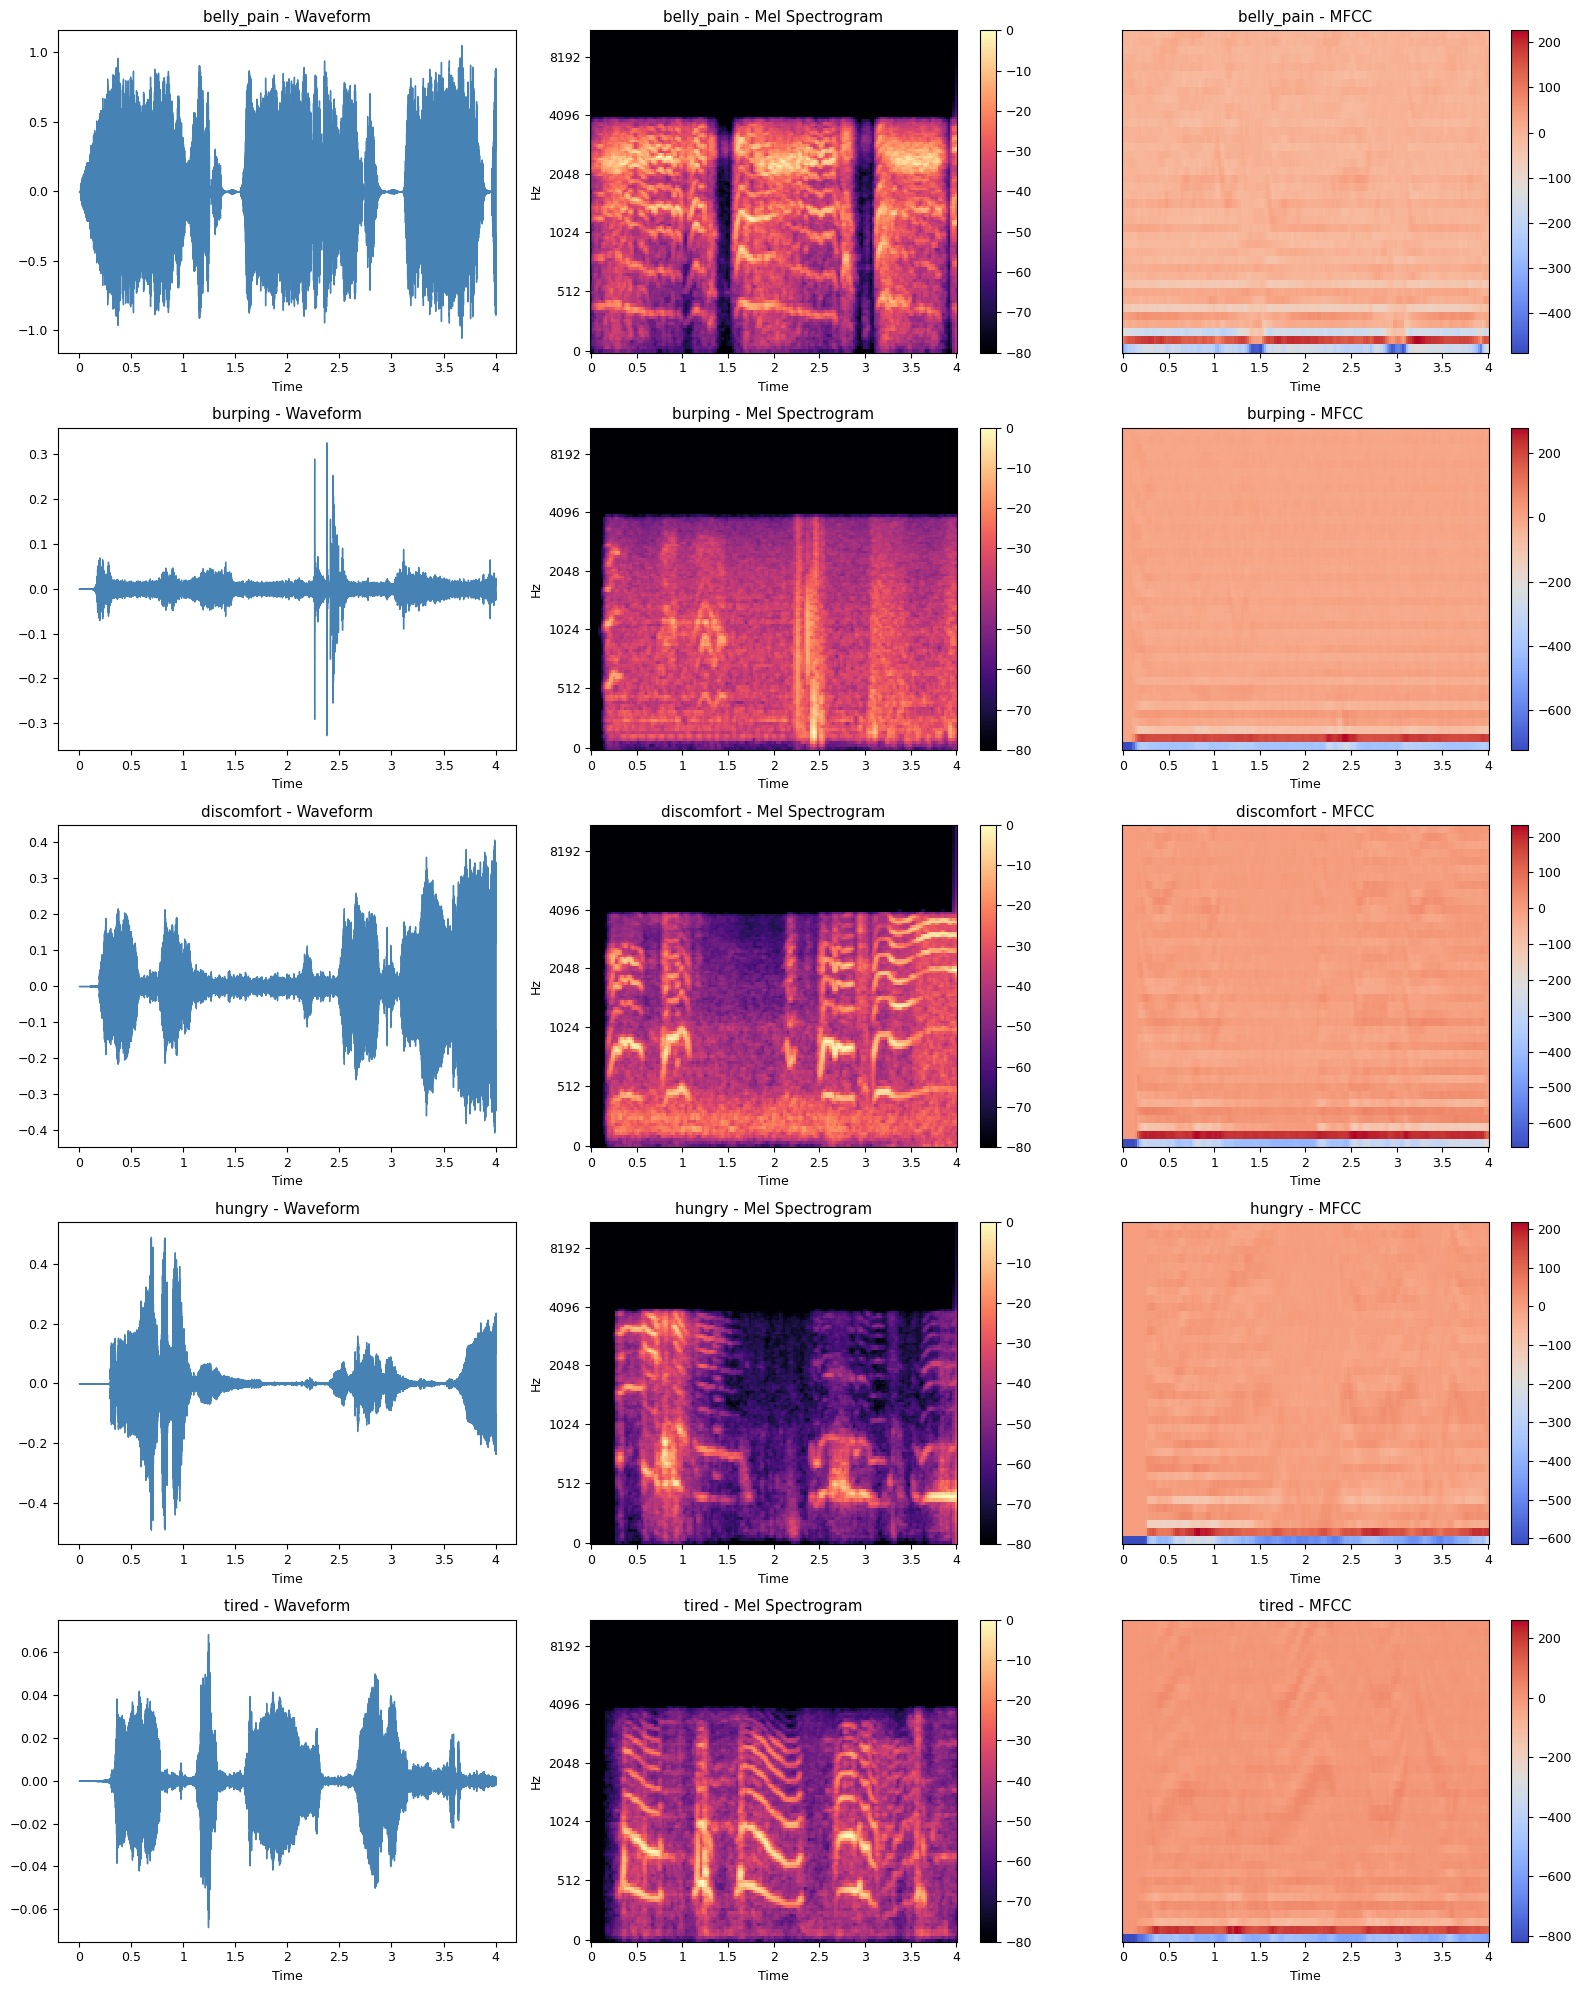

EDA complete


In [9]:
# STEP 4 — Exploratory Data Analysis
import librosa, librosa.display, matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 100, 'font.size': 9})
fig = plt.figure(figsize=(16, 4 * NUM_CLASSES))

for i, cls in enumerate(CLASSES):
    cls_dir = os.path.join(CFG['dataset_dir'], cls)

    # Added check to ensure directory exists and contains wav files
    if not os.path.isdir(cls_dir):
        print(f"Warning: Directory '{cls_dir}' not found. Skipping {cls} class for EDA.")
        continue

    wavs = [f for f in os.listdir(cls_dir) if f.endswith('.wav')]
    if not wavs:
        print(f"Warning: No .wav files found in '{cls_dir}'. Skipping {cls} class for EDA.")
        continue

    y, sr   = librosa.load(os.path.join(cls_dir, wavs[0]),
                            sr=CFG['sample_rate'], duration=CFG['duration'])

    ax1 = fig.add_subplot(NUM_CLASSES, 3, i*3+1)
    librosa.display.waveshow(y, sr=sr, ax=ax1, color='steelblue')
    ax1.set_title(f'{cls} - Waveform')

    ax2  = fig.add_subplot(NUM_CLASSES, 3, i*3+2)
    mel  = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=CFG['n_mels'])
    mdb  = librosa.power_to_db(mel, ref=np.max)
    img  = librosa.display.specshow(mdb, sr=sr, ax=ax2, cmap='magma', x_axis='time', y_axis='mel')
    fig.colorbar(img, ax=ax2)
    ax2.set_title(f'{cls} - Mel Spectrogram')

    ax3  = fig.add_subplot(NUM_CLASSES, 3, i*3+3)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=CFG['n_mfcc'])
    img2 = librosa.display.specshow(mfcc, sr=sr, ax=ax3, cmap='coolwarm', x_axis='time')
    fig.colorbar(img2, ax=ax3)
    ax3.set_title(f'{cls} - MFCC')

plt.tight_layout()
plt.savefig('/content/eda.png', bbox_inches='tight')
plt.show()
print('EDA complete')

In [11]:
# STEP 5 — Audio augmentation pipeline
!pip install audiomentations -q
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift

AUGMENT = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    TimeStretch(min_rate=0.85, max_rate=1.15, p=0.5),
    PitchShift(min_semitones=-3, max_semitones=3, p=0.4),
    Shift(min_shift=-0.3, max_shift=0.3, p=0.3),
])

def augment_audio(y, sr, n=2):
    results = []
    for _ in range(n):
        try:
            results.append(AUGMENT(samples=y.astype(np.float32), sample_rate=sr))
        except Exception:
            results.append(y.copy())
    return results

print('Augmentation pipeline ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 19.2 MB/s eta 0:00:00
Augmentation pipeline ready


In [12]:
# STEP 6 — Feature extraction (MFCC, Mel, Chroma, Spectral, Tonnetz, F0)
def load_pad(path, sr, max_len):
    try:
        y, _ = librosa.load(path, sr=sr)
    except Exception:
        return None
    y = librosa.util.normalize(y)
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    return y[:max_len].astype(np.float32)

def extract_1d(y, sr):
    feats = []
    mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=CFG['n_mfcc'],
                                   n_fft=CFG['n_fft'], hop_length=CFG['hop_length'])
    for arr in [mfcc, librosa.feature.delta(mfcc), librosa.feature.delta(mfcc, order=2)]:
        feats += [arr.mean(1), arr.std(1), arr.max(1), arr.min(1)]
    mel   = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=CFG['n_mels'],
                                            n_fft=CFG['n_fft'], hop_length=CFG['hop_length'])
    mdb   = librosa.power_to_db(mel, ref=np.max)
    feats += [mdb.mean(1), mdb.std(1)]
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=CFG['n_fft'], hop_length=CFG['hop_length'])
    feats += [chroma.mean(1), chroma.std(1)]
    for fn in [
        lambda: librosa.feature.spectral_centroid(y=y, sr=sr),
        lambda: librosa.feature.spectral_bandwidth(y=y, sr=sr),
        lambda: librosa.feature.spectral_rolloff(y=y, sr=sr),
        lambda: librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=CFG['n_fft']),
        lambda: librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr),
        lambda: librosa.feature.zero_crossing_rate(y),
        lambda: librosa.feature.rms(y=y),
    ]:
        a = fn()
        feats += [a.mean(1), a.std(1)]
    try:
        f0, _, _ = librosa.pyin(y, fmin=50, fmax=1000, sr=sr)
        f0c = f0[~np.isnan(f0)] if f0 is not None else np.array([0.0])
        feats.append(np.array([f0c.mean(), f0c.std(), f0c.max()] if len(f0c) else [0,0,0]))
    except Exception:
        feats.append(np.array([0.0, 0.0, 0.0]))
    return np.concatenate([f.flatten() for f in feats]).astype(np.float32)

def extract_2d(y, sr):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=CFG['n_mels'],
                                          n_fft=CFG['n_fft'], hop_length=CFG['hop_length'],
                                          fmax=CFG['fmax'])
    mdb = librosa.power_to_db(mel, ref=np.max)
    w   = CFG['mel_width']
    if mdb.shape[1] < w:
        mdb = np.pad(mdb, ((0,0),(0, w - mdb.shape[1])))
    return mdb[:, :w].astype(np.float32)

print('Feature functions ready')

Feature functions ready


In [13]:
# STEP 7 — Build full dataset with augmentation
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

X1_all, X2_all, y_all = [], [], []
label_enc = LabelEncoder()
label_enc.fit(CLASSES)

for cls in tqdm(CLASSES, desc='Classes'):
    cls_dir = os.path.join(CFG['dataset_dir'], cls)
    wavs    = [f for f in os.listdir(cls_dir) if f.endswith('.wav')]
    lbl     = label_enc.transform([cls])[0]
    for fname in tqdm(wavs, desc=f'  {cls}', leave=False):
        ya = load_pad(os.path.join(cls_dir, fname), CFG['sample_rate'], MAX_LEN)
        if ya is None: continue
        X1_all.append(extract_1d(ya, CFG['sample_rate']))
        X2_all.append(extract_2d(ya, CFG['sample_rate']))
        y_all.append(lbl)
        if CFG['augment']:
            for aug in augment_audio(ya, CFG['sample_rate'], CFG['aug_factor']):
                X1_all.append(extract_1d(aug, CFG['sample_rate']))
                X2_all.append(extract_2d(aug, CFG['sample_rate']))
                y_all.append(lbl)

X1 = np.array(X1_all)
X2 = np.array(X2_all)[..., np.newaxis]
y  = np.array(y_all)
print(f'1D features : {X1.shape}')
print(f'2D spectrograms: {X2.shape}')
for i, c in enumerate(CLASSES):
    print(f'  {c:<20s}: {(y==i).sum()} samples')

Classes: 100%|██████████| 5/5 [34:57<00:00, 419.41s/it]

1D features : (1828, 799)
2D spectrograms: (1828, 128, 173, 1)
  belly_pain          : 64 samples
  burping             : 32 samples
  discomfort          : 108 samples
  hungry              : 1528 samples
  tired               : 96 samples


In [14]:
# STEP 8 — Train/Val/Test split and normalization
import joblib

X1_tv,X1_te,X2_tv,X2_te,y_tv,y_te = train_test_split(
    X1, X2, y, test_size=CFG['test_split'], stratify=y, random_state=CFG['seed'])

vr = CFG['val_split'] / (1 - CFG['test_split'])
X1_tr,X1_va,X2_tr,X2_va,y_tr,y_va = train_test_split(
    X1_tv, X2_tv, y_tv, test_size=vr, stratify=y_tv, random_state=CFG['seed'])

scaler  = StandardScaler()
X1_tr   = scaler.fit_transform(X1_tr)
X1_va   = scaler.transform(X1_va)
X1_te   = scaler.transform(X1_te)

def norm2d(X):
    mn = X.min(axis=(1,2,3), keepdims=True)
    mx = X.max(axis=(1,2,3), keepdims=True)
    return (X - mn) / (mx - mn + 1e-8)

X2_tr = norm2d(X2_tr)
X2_va = norm2d(X2_va)
X2_te = norm2d(X2_te)

joblib.dump(scaler, '/content/models/scaler.pkl')
np.save('/content/models/label_classes.npy', label_enc.classes_)
print(f'Train:{len(y_tr)}  Val:{len(y_va)}  Test:{len(y_te)}')

Train:1278  Val:275  Test:275


In [15]:
# STEP 9 — CNN with Squeeze-Excitation Attention
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

y_tr_c = to_categorical(y_tr, NUM_CLASSES)
y_va_c = to_categorical(y_va, NUM_CLASSES)
y_te_c = to_categorical(y_te, NUM_CLASSES)
IN2D   = X2_tr.shape[1:]

def se_block(x, r=16):
    c  = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(c//r, activation='relu')(se)
    se = layers.Dense(c, activation='sigmoid')(se)
    se = layers.Reshape((1,1,c))(se)
    return layers.Multiply()([x, se])

def conv_block(x, f, pool=(2,2)):
    x = layers.Conv2D(f,(3,3),padding='same',kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(f,(3,3),padding='same',kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = se_block(x)
    x = layers.MaxPooling2D(pool)(x)
    return layers.Dropout(0.25)(x)

def build_cnn(in_shape, nc):
    inp = layers.Input(shape=in_shape)
    x   = conv_block(inp, 32)
    x   = conv_block(x,  64)
    x   = conv_block(x,  128)
    x   = conv_block(x,  256)
    gap = layers.GlobalAveragePooling2D()(x)
    gmp = layers.GlobalMaxPooling2D()(x)
    x   = layers.Concatenate()([gap, gmp])
    x   = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.5)(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(nc, activation='softmax')(x)
    return models.Model(inp, out, name='CNN_SE')

cnn = build_cnn(IN2D, NUM_CLASSES)
cnn.compile(optimizer=optimizers.AdamW(learning_rate=CFG['lr'], weight_decay=1e-4),
            loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weights = dict(enumerate(cw))

cbs = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=15,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=7, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('/content/models/cnn_best.h5',
                               monitor='val_accuracy', save_best_only=True),
]

print('Training CNN-SE...')
cnn_hist = cnn.fit(X2_tr, y_tr_c, validation_data=(X2_va, y_va_c),
                   epochs=CFG['epochs'], batch_size=CFG['batch_size'],
                   callbacks=cbs, class_weight=class_weights, verbose=1)
print('CNN training complete!')

Model: "CNN_SE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 173,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 173,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 173,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 173,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 173,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 173,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 173,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │         96 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128, 173,  │          0 │ activation_1[0][… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 86,    │          0 │ multiply[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 86,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 86,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 86,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 86,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 86,    │     36,928 │ activation_2[0][

 Total params: 1,584,227 (6.04 MB)

 Trainable params: 1,581,283 (6.03 MB)

 Non-trainable params: 2,944 (11.50 KB)

Training CNN-SE...
Epoch 1/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.3631 - loss: 2.2033

40/40 ━━━━━━━━━━━━━━━━━━━━ 60s 760ms/step - accuracy: 0.3616 - loss: 2.2066 - val_accuracy: 0.0509 - val_loss: 1.6529 - learning_rate: 0.0010
Epoch 2/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.2383 - loss: 1.9815 - val_accuracy: 0.0509 - val_loss: 2.0102 - learning_rate: 0.0010
Epoch 3/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.2471 - loss: 1.8285 - val_accuracy: 0.0509 - val_loss: 2.8007 - learning_rate: 0.0010
Epoch 4/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.2534 - loss: 1.6419 - val_accuracy: 0.0509 - val_loss: 1.9050 - learning_rate: 0.0010
Epoch 5/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.2130 - loss: 1.7863 - val_accuracy: 0.0509 - val_loss: 4.6378 - learning_rate: 0.0010
Epoch 6/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.2622 - loss: 1.7289 - val_accuracy: 0.0509 - val_loss: 3.7373 - learning_rate: 0.0010
Epoch 7/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.2679 - loss: 1.4582 - val_accuracy: 0

40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.2839 - loss: 1.3529 - val_accuracy: 0.8218 - val_loss: 2.0643 - learning_rate: 5.0000e-04
Epoch 10/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.3576 - loss: 1.0832 - val_accuracy: 0.0509 - val_loss: 4.8858 - learning_rate: 5.0000e-04
Epoch 11/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.3678 - loss: 0.9879 - val_accuracy: 0.0509 - val_loss: 3.9691 - learning_rate: 5.0000e-04
Epoch 12/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.4183 - loss: 0.9778 - val_accuracy: 0.0509 - val_loss: 5.6141 - learning_rate: 5.0000e-04
Epoch 13/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.3823 - loss: 1.0201 - val_accuracy: 0.2509 - val_loss: 2.9645 - learning_rate: 5.0000e-04
Epoch 14/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.4236 - loss: 0.9078 - val_accuracy: 0.0945 - val_loss: 3.1186 - learning_rate: 5.0000e-04
Epoch 15/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4291 - los

In [16]:
# STEP 10 — CNN-BiLSTM with Self-Attention (dual-input fusion)
IN1D = X1_tr.shape[1]

def build_hybrid(in2d, in1d, nc):
    mel_in = layers.Input(shape=in2d, name='mel')
    x = layers.Conv2D(64,(3,3), activation='relu', padding='same')(mel_in)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128,(3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,4))(x)
    x = layers.Conv2D(256,(3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    x = layers.Reshape((h, w*c))(x)
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.3, implementation=2))(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.3, implementation=2))(x)
    q = layers.Dense(64)(x)
    k = layers.Dense(64)(x)
    v = layers.Dense(128)(x)
    sc = layers.Dot(axes=[2,2])([q,k])
    sc = layers.Softmax()(sc)
    x  = layers.Dot(axes=[2,1])([sc,v])
    x  = layers.GlobalAveragePooling1D()(x)
    fi = layers.Input(shape=(in1d,), name='feat')
    f  = layers.Dense(512, activation='relu')(fi)
    f  = layers.BatchNormalization()(f)
    f  = layers.Dropout(0.4)(f)
    f  = layers.Dense(256, activation='relu')(f)
    f  = layers.BatchNormalization()(f)
    f  = layers.Dropout(0.3)(f)
    f  = layers.Dense(128, activation='relu')(f)
    m  = layers.Concatenate()([x, f])
    m  = layers.Dense(256, activation='relu')(m)
    m  = layers.BatchNormalization()(m)
    m  = layers.Dropout(0.4)(m)
    m  = layers.Dense(128, activation='relu')(m)
    m  = layers.Dropout(0.3)(m)
    out = layers.Dense(nc, activation='softmax')(m)
    return models.Model([mel_in, fi], out, name='CNN_BiLSTM_Attn')

hybrid = build_hybrid(IN2D, IN1D, NUM_CLASSES)
hybrid.compile(optimizer=optimizers.AdamW(learning_rate=CFG['lr']*0.5, weight_decay=1e-4),
               loss='categorical_crossentropy', metrics=['accuracy'])
hybrid.summary()

cbs2 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=15,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=7, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('/content/models/hybrid_best.h5',
                               monitor='val_accuracy', save_best_only=True),
]

print('Training CNN-BiLSTM-Attention...')
hyb_hist = hybrid.fit([X2_tr, X1_tr], y_tr_c,
                       validation_data=([X2_va, X1_va], y_va_c),
                       epochs=CFG['epochs'], batch_size=CFG['batch_size'],
                       callbacks=cbs2, class_weight=class_weights, verbose=1)
print('Hybrid training complete!')

Model: "CNN_BiLSTM_Attn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mel (InputLayer)    │ (None, 128, 173,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 173,  │        640 │ mel[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 173,  │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 86,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 86,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 86,    │        512 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 21,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 21,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 21,    │      1,024 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 10,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 16, 2560)  │          0 │ max_pooling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat (InputLayer)   │ (None, 799)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 16, 512)   │  5,769,216 │ reshape_4[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 512)       │    409,600 │ feat[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 16, 256)   │    656,384 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_14[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 16, 64)    │     16,448 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 16, 64)    │     16,448 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,540,101 (28.76 MB)

 Trainable params: 7,537,157 (28.75 MB)

 Non-trainable params: 2,944 (11.50 KB)

...

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.9139 - loss: 0.0870 - val_accuracy: 0.8836 - val_loss: 0.3582 - learning_rate: 2.5000e-04
Epoch 45/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.9052 - loss: 0.1102 - val_accuracy: 0.8800 - val_loss: 0.3461 - learning_rate: 2.5000e-04
Epoch 46/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.9289 - loss: 0.0768 - val_accuracy: 0.8800 - val_loss: 0.3448 - learning_rate: 2.5000e-04
Epoch 47/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9392 - loss: 0.0533

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.9393 - loss: 0.0535 - val_accuracy: 0.8909 - val_loss: 0.3360 - learning_rate: 2.5000e-04
Epoch 48/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9404 - loss: 0.0571

40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.9406 - loss: 0.0571 - val_accuracy: 0.8945 - val_loss: 0.3297 - learning_rate: 2.5000e-04
Epoch 49/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9445 - loss: 0.0576

40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.9447 - loss: 0.0576 - val_accuracy: 0.9055 - val_loss: 0.3233 - learning_rate: 2.5000e-04
Epoch 50/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.9410 - loss: 0.0696 - val_accuracy: 0.9018 - val_loss: 0.3501 - learning_rate: 2.5000e-04
Epoch 51/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.9405 - loss: 0.0561 - val_accuracy: 0.9055 - val_loss: 0.3240 - learning_rate: 2.5000e-04
Epoch 52/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.9458 - loss: 0.0551 - val_accuracy: 0.8873 - val_loss: 0.3436 - learning_rate: 2.5000e-04
Epoch 53/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.9519 - loss: 0.0536 - val_accuracy: 0.8691 - val_loss: 0.4432 - learning_rate: 2.5000e-04
Epoch 54/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.9493 - loss: 0.0483 - val_accuracy: 0.9018 - val_loss: 0.3335 - learning_rate: 2.5000e-04
Epoch 55/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.94

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.9494 - loss: 0.0557 - val_accuracy: 0.9200 - val_loss: 0.3206 - learning_rate: 2.5000e-04
Epoch 56/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.9535 - loss: 0.0373 - val_accuracy: 0.9200 - val_loss: 0.3486 - learning_rate: 2.5000e-04
Epoch 57/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.9647 - loss: 0.0352 - val_accuracy: 0.9055 - val_loss: 0.3246 - learning_rate: 2.5000e-04
Epoch 58/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.9643 - loss: 0.0324 - val_accuracy: 0.9200 - val_loss: 0.3140 - learning_rate: 2.5000e-04
Epoch 59/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.9581 - loss: 0.0387 - val_accuracy: 0.9200 - val_loss: 0.2936 - learning_rate: 2.5000e-04
Epoch 60/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.9588 - loss: 0.0347 - val_accuracy: 0.9055 - val_loss: 0.3124 - learning_rate: 2.5000e-04
Epoch 61/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.975

In [17]:
# STEP 11 — Classical ML Ensemble: XGBoost + LightGBM + RandomForest + SVM
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
import lightgbm as lgb

pca      = PCA(n_components=150, random_state=CFG['seed'])
X1_tr_p  = pca.fit_transform(X1_tr)
X1_va_p  = pca.transform(X1_va)
X1_te_p  = pca.transform(X1_te)
joblib.dump(pca, '/content/models/pca.pkl')
print(f'PCA: {X1_tr.shape[1]} -> {X1_tr_p.shape[1]} dims')

rf   = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                               random_state=CFG['seed'], n_jobs=-1)
xgb  = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      eval_metric='mlogloss', random_state=CFG['seed'], n_jobs=-1)
lgbm = lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                            class_weight='balanced', random_state=CFG['seed'], n_jobs=-1)
svm  = SVC(kernel='rbf', C=10, gamma='scale', probability=True, class_weight='balanced')

ml_ens = VotingClassifier(
    estimators=[('rf',rf),('xgb',xgb),('lgb',lgbm),('svm',svm)],
    voting='soft', n_jobs=-1)

print('Training ML Ensemble (RF + XGBoost + LightGBM + SVM)...')
ml_ens.fit(X1_tr_p, y_tr)
joblib.dump(ml_ens, '/content/models/ml_ensemble.pkl')
print('ML ensemble training complete!')

PCA: 799 -> 150 dims
Training ML Ensemble (RF + XGBoost + LightGBM + SVM)...
ML ensemble training complete!


9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 328ms/step
CNN-SE Accuracy: 83.27%
              precision    recall  f1-score   support

  belly_pain       0.00      0.00      0.00        10
     burping       0.00      0.00      0.00         5
  discomfort       0.00      0.00      0.00        16
      hungry       0.84      0.99      0.91       230
       tired       0.33      0.07      0.12        14

    accuracy                           0.83       275
   macro avg       0.23      0.21      0.21       275
weighted avg       0.72      0.83      0.77       275



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


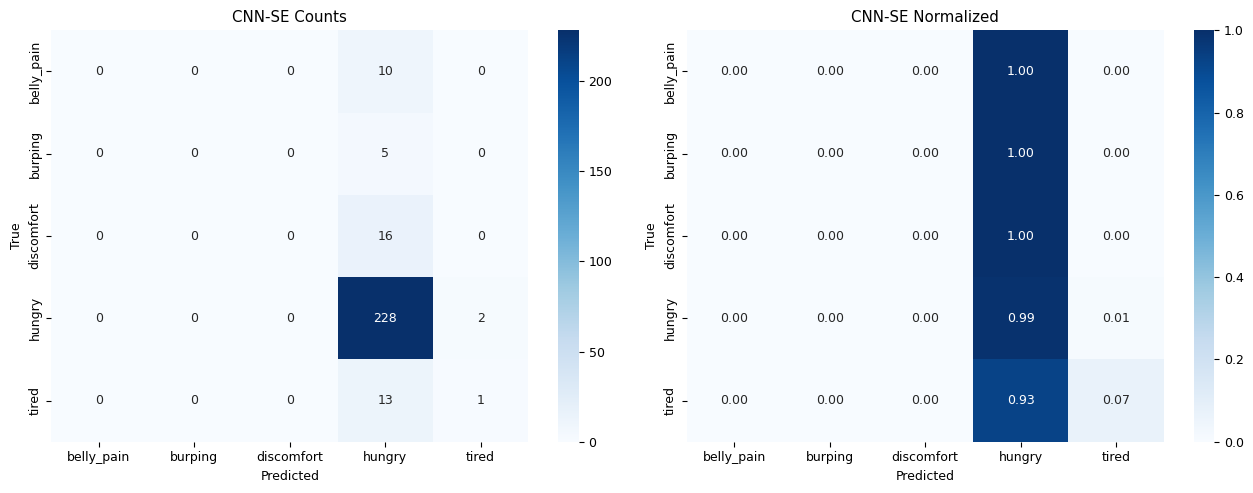

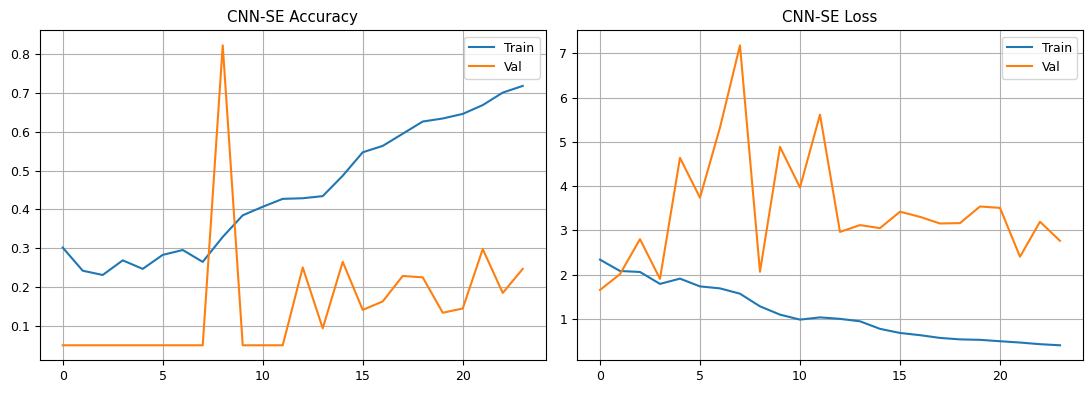

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
CNN-BiLSTM Accuracy: 92.00%
              precision    recall  f1-score   support

  belly_pain       1.00      0.90      0.95        10
     burping       0.80      0.80      0.80         5
  discomfort       0.68      0.81      0.74        16
      hungry       0.95      0.95      0.95       230
       tired       0.67      0.57      0.62        14

    accuracy                           0.92       275
   macro avg       0.82      0.81      0.81       275
weighted avg       0.92      0.92      0.92       275



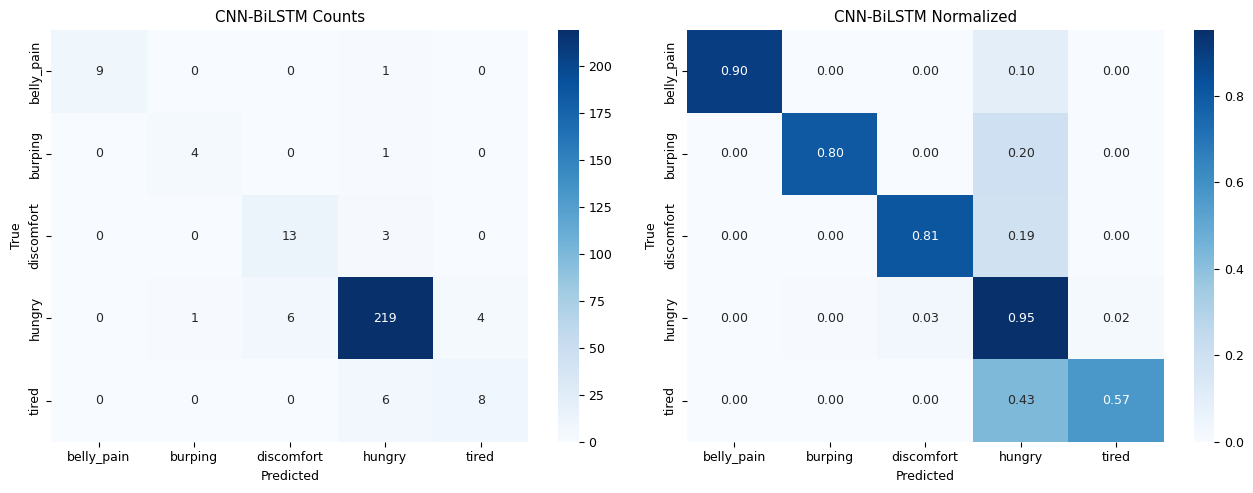

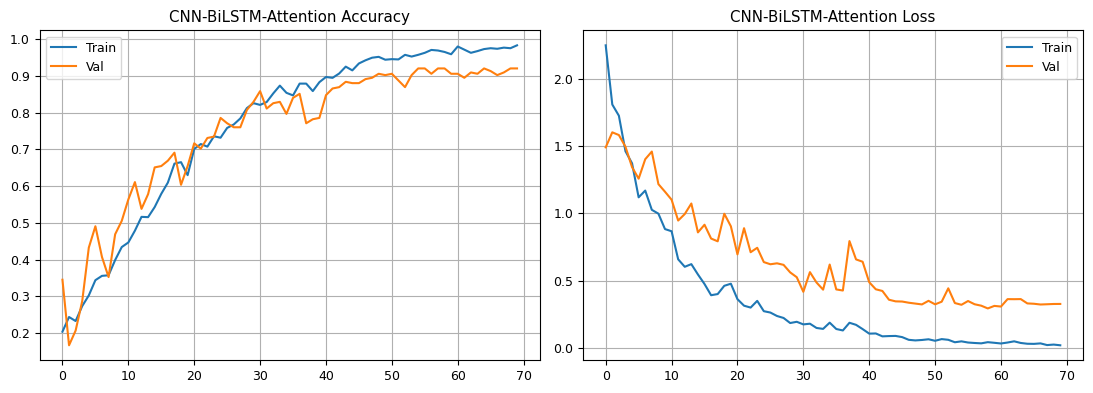

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ML Ensemble Accuracy: 88.36%
              precision    recall  f1-score   support

  belly_pain       1.00      0.40      0.57        10
     burping       1.00      0.40      0.57         5
  discomfort       1.00      0.38      0.55        16
      hungry       0.88      1.00      0.93       230
       tired       1.00      0.07      0.13        14

    accuracy                           0.88       275
   macro avg       0.98      0.45      0.55       275
weighted avg       0.90      0.88      0.85       275



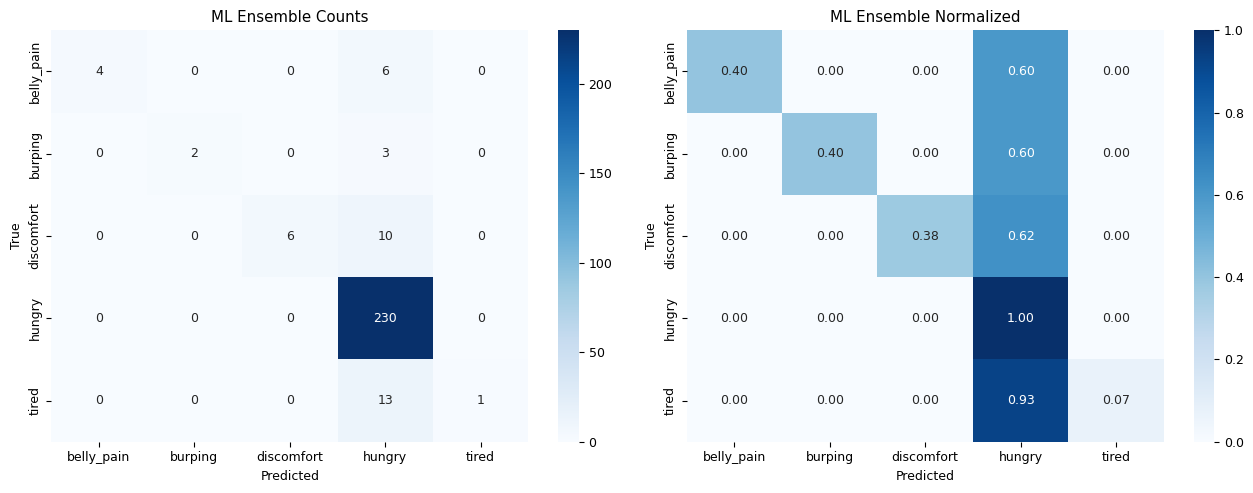

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


FINAL ENSEMBLE ACCURACY: 93.09%


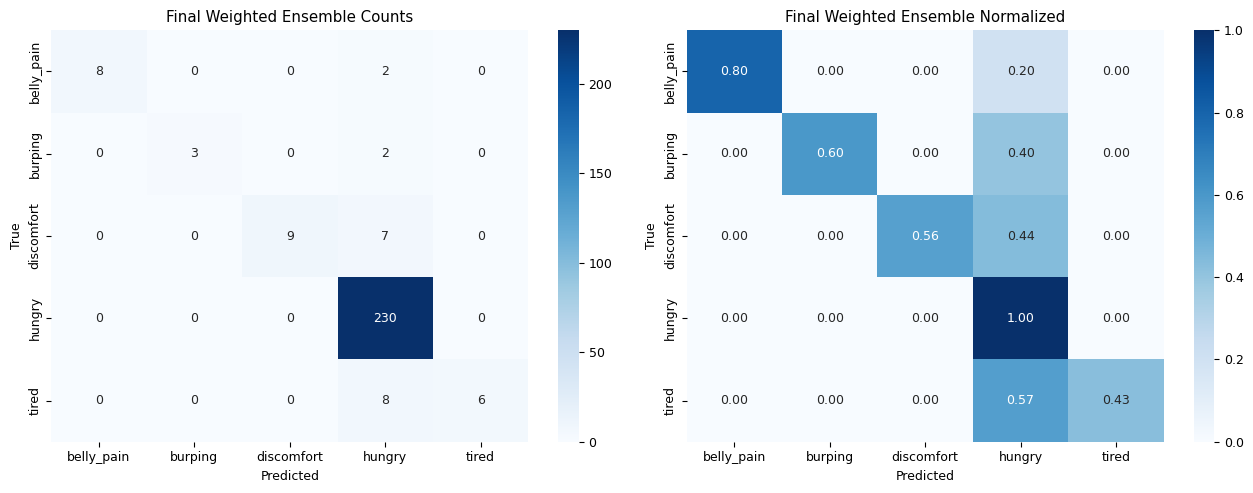

Weights -> CNN:0.313  Hybrid:0.350  ML:0.337


In [18]:
# STEP 12 — Full evaluation with confusion matrices
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def plot_cm(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    cmn  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1,2,figsize=(13,5))
    for ax,data,fmt,t in zip(axes,[cm,cmn],['d','.2f'],[title+' Counts',title+' Normalized']):
        sns.heatmap(data,annot=True,fmt=fmt,cmap='Blues',
                    xticklabels=CLASSES,yticklabels=CLASSES,ax=ax)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(t)
    plt.tight_layout(); plt.show()

def plot_history(hist, title):
    fig,(a,b) = plt.subplots(1,2,figsize=(11,4))
    a.plot(hist.history['accuracy'],label='Train')
    a.plot(hist.history['val_accuracy'],label='Val')
    a.set_title(f'{title} Accuracy'); a.legend(); a.grid(True)
    b.plot(hist.history['loss'],label='Train')
    b.plot(hist.history['val_loss'],label='Val')
    b.set_title(f'{title} Loss'); b.legend(); b.grid(True)
    plt.tight_layout(); plt.show()

# CNN
cnn_p   = cnn.predict(X2_te)
cnn_acc = (cnn_p.argmax(1)==y_te).mean()
print(f'CNN-SE Accuracy: {cnn_acc*100:.2f}%')
print(classification_report(y_te, cnn_p.argmax(1), target_names=CLASSES))
plot_cm(y_te, cnn_p.argmax(1), 'CNN-SE')
plot_history(cnn_hist, 'CNN-SE')

# Hybrid
hyb_p   = hybrid.predict([X2_te, X1_te])
hyb_acc = (hyb_p.argmax(1)==y_te).mean()
print(f'CNN-BiLSTM Accuracy: {hyb_acc*100:.2f}%')
print(classification_report(y_te, hyb_p.argmax(1), target_names=CLASSES))
plot_cm(y_te, hyb_p.argmax(1), 'CNN-BiLSTM')
plot_history(hyb_hist, 'CNN-BiLSTM-Attention')

# ML Ensemble
ml_p   = ml_ens.predict_proba(X1_te_p)
ml_acc = (ml_p.argmax(1)==y_te).mean()
print(f'ML Ensemble Accuracy: {ml_acc*100:.2f}%')
print(classification_report(y_te, ml_p.argmax(1), target_names=CLASSES))
plot_cm(y_te, ml_p.argmax(1), 'ML Ensemble')

# Weighted final ensemble
cnn_va = max(cnn_hist.history['val_accuracy'])
hyb_va = max(hyb_hist.history['val_accuracy'])
ml_va  = ml_ens.score(X1_va_p, y_va)
total  = cnn_va + hyb_va + ml_va
wc,wh,wm = cnn_va/total, hyb_va/total, ml_va/total
ens_p  = wc*cnn_p + wh*hyb_p + wm*ml_p
ens_acc = (ens_p.argmax(1)==y_te).mean()
print(f'FINAL ENSEMBLE ACCURACY: {ens_acc*100:.2f}%')
plot_cm(y_te, ens_p.argmax(1), 'Final Weighted Ensemble')
np.save('/content/models/ensemble_weights.npy', np.array([wc,wh,wm]))
print(f'Weights -> CNN:{wc:.3f}  Hybrid:{wh:.3f}  ML:{wm:.3f}')